# 02 — What the embeddings hold, and what a clustering can find in them

Notebook 01 established what the 1 506 files are. This one asks whether their ResNet50
embeddings carry the diagnosis at all: five clustering algorithms, the agreement of each one
with the labels, and the projection that shows what the space looks like.

Nothing here decides anything. Choosing a method on all the labels is exactly the mistake the
protocol was rebuilt to prevent, and notebook 03 shows how the choice is made inside a fold.

In [1]:
import numpy as np
import pandas as pd

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

## 1. Clustering the embeddings

Five algorithms on the ResNet50 embeddings, compared on internal metrics and on the ARI
against the labels.

**Where the ARI is computed matters.** In the corrected protocol it is computed on the
*training fold's* labels only, inside the fold. Here, in exploration, it is computed on all
of them — which is legitimate for looking at the data, and was exactly the mistake when the
same number was used to *choose* the method that produced the pseudo-labels.

In [2]:
from mri_semisupervised.config import ClusteringConfig, FeatureConfig
from mri_semisupervised.features.extractor import load_cached_features
from mri_semisupervised.models.clustering import (
    build_clustering_report,
    fit_agglomerative,
    fit_dbscan,
    fit_gmm,
    fit_kmeans,
    reduce_pca,
    standardise,
)

features, index_df = load_cached_features(FeatureConfig().cache_path)
truth = index_df["label_index"].to_numpy(dtype=float)

reduced, _ = standardise(features)
reduced, _ = reduce_pca(reduced, target_variance=ClusteringConfig().pca_variance)
print(f"{features.shape[1]} dimensions -> {reduced.shape[1]} components at 95% variance")

results = [
    fit_kmeans(reduced, truth, n_clusters=2),
    fit_agglomerative(reduced, truth, n_clusters=2, linkage="ward"),
    fit_agglomerative(reduced, truth, n_clusters=2, linkage="average"),
    fit_gmm(reduced, truth, n_components=2),
    fit_dbscan(reduced, truth, eps=8.0, min_samples=10),
]
build_clustering_report(results)

2048 dimensions -> 100 components at 95% variance


,method,n_clusters,silhouette,davies_bouldin,calinski_harabasz,ari_vs_truth,inertia,bic,aic,noise_ratio
0,Agglomerative(ward),2,0.077035,2.882369,132.213211,0.457136,NaN,NaN,NaN,NaN
1,GMM,2,0.208707,2.935275,153.197980,0.096560,NaN,719842.367409,665069.76239,NaN
2,KMeans,2,0.208122,2.851702,161.409038,0.072871,1604197.875,NaN,NaN,NaN
3,"DBSCAN(eps=8.0,min=10)",1,NaN,NaN,NaN,0.004856,NaN,NaN,NaN,0.991368
4,Agglomerative(average),2,0.718383,0.198511,20.956675,0.000000,NaN,NaN,NaN,NaN


### What the table says, and what it does not

Read the silhouette column beside the ARI column. `Agglomerative(average)` has the best
silhouette of the five and an ARI of zero: it found a very tight structure that has nothing
to do with the diagnosis — one cluster holding almost everything, and one holding a handful
of outliers.

An internal metric measures whether a partition is *neat*. It cannot tell you whether it is
*the one you wanted*. That is the whole reason the ARI is in the table.

DBSCAN, at this eps, declares nearly everything noise. The number is reported as it came: a
method that refuses to split is information about the embedding space.

best ARI against the labels: Agglomerative(ward) (0.457)


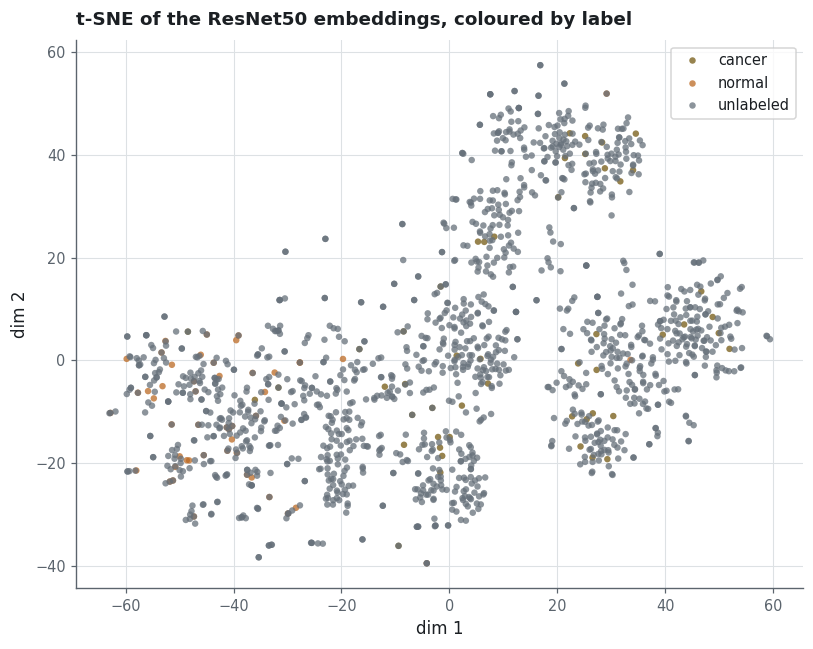

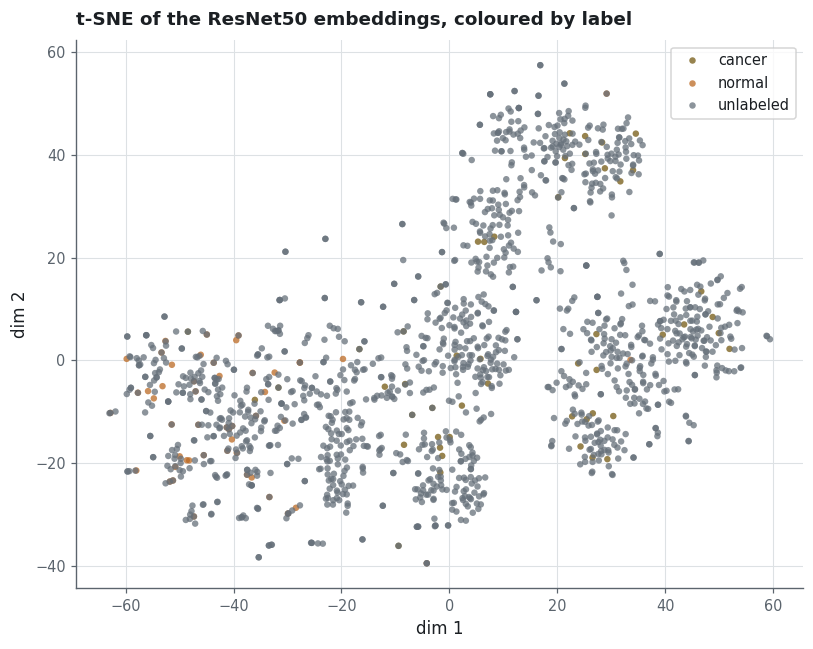

In [3]:
from mri_semisupervised.viz.plots import plot_2d_scatter, project_2d

best = max((r for r in results if r.ari_vs_truth is not None), key=lambda r: r.ari_vs_truth)
print(f"best ARI against the labels: {best.name} ({best.ari_vs_truth:.3f})")

coords = project_2d(reduced, method="tsne", seed=42)
labels = index_df["label_name"].fillna("unlabeled").tolist()
plot_2d_scatter(coords, labels, title="t-SNE of the ResNet50 embeddings, coloured by label")

## 2. Where this leaves the pseudo-labels

The best clustering reaches an ARI around 0.6 against the true labels. That is substantial
and far from decisive: the pseudo-labels it produces will be right often enough to be worth
trying, and wrong often enough that the trying has to be measured.

Notebook 03 measures it, under a protocol where the test fold takes part in no decision
and against a control that receives the same images with their pseudo-labels shuffled.